# Flat Core verbs — `points`, `polygons`, `choropleth`

The 3-D tier answers the same **Core vocabulary** as every other backend. These three verbs draw on the
**ground plane (`z = 0`)** — the *flat* members of a pair whose other half carries height. Because they are
flat, their 3-D value is the contrast with the raised sibling, so every scene is viewed in **perspective**
and each flat verb is shown next to the raised one.

The data is a **real WorldPop 2020 population raster over Luxembourg** (persons per cell), vectorized to
cells with pyramids `to_feature_collection`. *Source: WorldPop (www.worldpop.org), University of
Southampton — CC-BY-4.0.*

---
*Data.* All layers below are built from **real data downloaded with
[earthlens](https://github.com/serapeum-org/earthlens)** and committed as small fixtures under
`examples/data/`; vector and 3-D layers are derived from those real rasters through **pyramids** (the GIS
engine), so nothing here is synthetic. Attributions are given per dataset.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

import pyramids  # import first: bootstraps pyramids' vendored GDAL
from pyramids.dataset import Dataset
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'real_dem_mont_blanc.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

## `points()` vs `point_cloud()` — flat markers, then raised by the value

The population cells as flat markers on the ground, then the *same* cells fed to `point_cloud()` as an
`(x, y, z)` table with `z` set from the population count — the cloud lifts off the plane into 3-D.

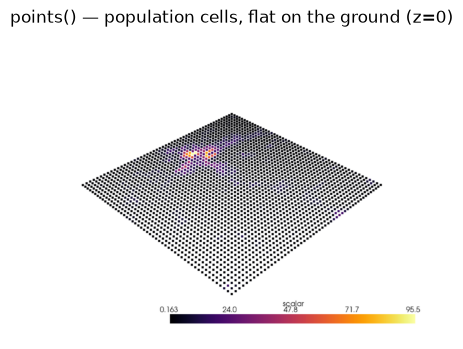

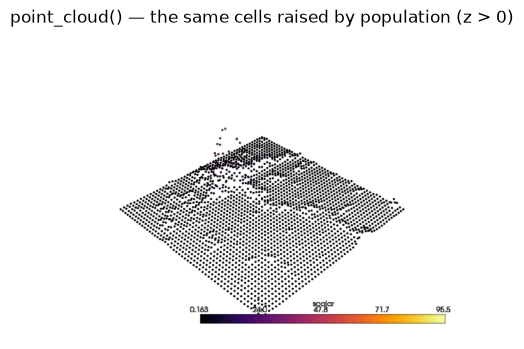

In [2]:
pop = Dataset.read_file(str(DATA / 'real_population.tif')).resample(0.006, method='nearest neighbor')
pts = pop.to_feature_collection(add_geometry='Point')
pts = pts[pts['Band_1'] >= 0]                       # drop nodata cells
people = pts['Band_1'].to_numpy(dtype=float)

# flat: markers on the ground plane, coloured by population
scene = Scene3D(off_screen=True)
scene.points(pts, column='Band_1', cmap='inferno', size=12.0)
scene.view('isometric')
show(scene, 'points() — population cells, flat on the ground (z=0)')
scene.close()

# raised: the same cells as an (x, y, z) cloud, z from population
xy = np.column_stack([pts.geometry.x.values, pts.geometry.y.values])
extent = max(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]))
z = people / (people.max() or 1.0) * 0.3 * extent   # scale height to ~30% of the map extent
scene = Scene3D(off_screen=True)
scene.point_cloud(np.column_stack([xy, z]), values=people, cmap='inferno', size=12.0)
scene.view('isometric')
show(scene, 'point_cloud() — the same cells raised by population (z > 0)')
scene.close()

## `polygons()` vs `extruded_polygons()` — flat fill, then raised prisms

A coarser cell grid so each footprint is visible. `polygons()` fills them flat; `extruded_polygons()`
raises each by its population into a 3-D block field.

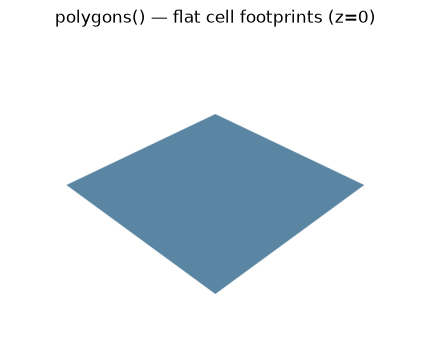

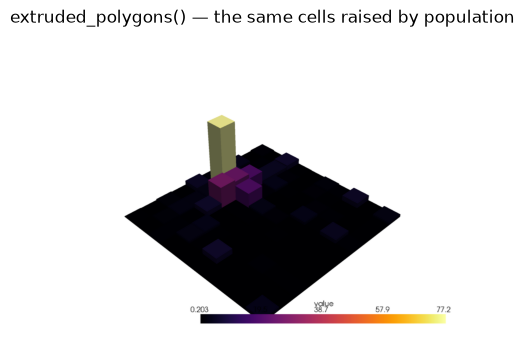

In [3]:
grid_pop = Dataset.read_file(str(DATA / 'real_population.tif')).resample(0.03, method='nearest neighbor')
cells = grid_pop.to_feature_collection(add_geometry='Polygon')
cells = cells[cells['Band_1'] >= 0].reset_index(drop=True)
span = max(cells.total_bounds[2] - cells.total_bounds[0], cells.total_bounds[3] - cells.total_bounds[1])
cells['tower'] = cells['Band_1'] / (cells['Band_1'].max() or 1.0) * 0.4 * span

scene = Scene3D(off_screen=True)
scene.polygons(cells, color='steelblue', opacity=0.85)
scene.view('isometric')
show(scene, 'polygons() — flat cell footprints (z=0)')
scene.close()

scene = Scene3D(off_screen=True)
scene.extruded_polygons(cells, height='tower', column='Band_1', cmap='inferno')
scene.view('isometric')
show(scene, 'extruded_polygons() — the same cells raised by population')
scene.close()

## `choropleth()` vs a classed extrusion — flat classes, then raised classes

`choropleth` requires a `column` and classifies it (here population into quantiles). The raised sibling is
`extruded_polygons` given the same `column` *and* a `height`, so each class recolours *and* rises.

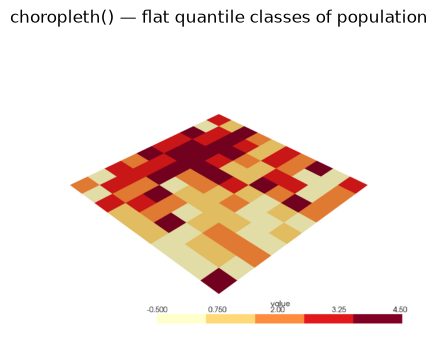

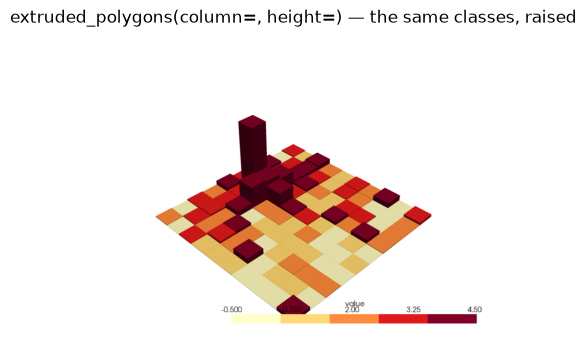

In [4]:
scene = Scene3D(off_screen=True)
scene.choropleth(cells, column='Band_1', scheme='quantiles', k=5, cmap='YlOrRd')
scene.view('isometric')
show(scene, 'choropleth() — flat quantile classes of population')
scene.close()

scene = Scene3D(off_screen=True)
scene.extruded_polygons(cells, height='tower', column='Band_1', scheme='quantiles', k=5, cmap='YlOrRd')
scene.view('isometric')
show(scene, 'extruded_polygons(column=, height=) — the same classes, raised')
scene.close()

**Recap.** `points`/`polygons`/`choropleth` draw flat on the ground plane — their job is to *annotate* a
3-D scene. When the data carries height, reach for the raised sibling: `point_cloud` for an `(x, y, z)`
cloud and `extruded_polygons` for prisms.